<a href="https://colab.research.google.com/github/vinifrts/nba-performance-salary-retention-analysis/blob/main/nba_performance_salary_retention_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Descritiva de Desempenho e Salários na NBA

Disciplina: Métodos Quantitativos  
Curso: Ciência da Computação  
Professor: Carubbi

Equipe analisada: Golden State Warriors  

Integrantes do grupo:
Vinícius Freitas - 2422972

João Pedro Muniz - 2413088


TEAM ID DATASET - GS

O objetivo deste trabalho é investigar, no nível jogador-temporada, se há associação observacional entre desempenho, utilização em quadra, salário e a não permanência observada no mesmo time na temporada seguinte para a equipe do Golden State Warriors ao longo de todas as temporadas disponíveis no dataset.

## CARREGAMENTO DOS DADOS

In [ ]:
# Importação das bibliotecas.
from pathlib import Path
import os
from gdown import download
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#configs dos gráficos
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [ ]:
# Definir a função download_from_drive
def download_from_drive(link,filename):

    # Criar a pasta para download
    foldername = filename.split('/')[0]
    if not os.path.exists(foldername):
        os.makedirs(foldername)
    else:
        print(f'A pasta {foldername} já existe!')

    # Extrair o ID do arquivo a partir do link do Google Drive
    file_id = link.split('/')[5]
    # Criar a URL de download usando o ID do arquivo
    url = f'https://drive.google.com/uc?id={file_id}'
    download(url, filename, quiet = False)

In [ ]:
# Download arquivo CSV e figuras PNG
url_dataset = 'https://drive.google.com/file/d/1WOzabGvTmyTcjWIsDRO0wjrybwLubnyu/view?usp=share_link'
dst_dataset = 'dataset/nba_stats_preprocessed.csv'

download_from_drive(url_dataset,dst_dataset)

A pasta dataset já existe!


Downloading...
From: https://drive.google.com/uc?id=1WOzabGvTmyTcjWIsDRO0wjrybwLubnyu
To: /content/dataset/nba_stats_preprocessed.csv
100%|██████████| 2.44M/2.44M [00:00<00:00, 65.5MB/s]


In [ ]:
# Lê o CSV original e cria uma cópia de trabalho.
df_raw = pd.read_csv("/content/dataset/nba_stats_preprocessed.csv")
df = df_raw.copy()
df.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,informacoes_recrutamento,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg
0,1999,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,0.0,5.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,15,9000000.0,1975-06-07,24.0,NaN,NaN,NaN
1,2000,Allen Iverson,366,allen-iverson,SG,PHI,inactive,70.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,27,10125000.0,1975-06-07,25.0,NaN,NaN,NaN
2,2001,Allen Iverson,366,allen-iverson,SG,PHI,inactive,71.0,0.0,18.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,17,11250000.0,1975-06-07,26.0,NaN,NaN,NaN
3,2002,Allen Iverson,366,allen-iverson,SG,PHI,inactive,60.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,14,12375000.0,1975-06-07,27.0,NaN,NaN,NaN
4,2003,Allen Iverson,366,allen-iverson,SG,PHI,inactive,82.0,0.0,8.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,11,13500000.0,1975-06-07,28.0,NaN,NaN,NaN
5,2004,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,0.0,7.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,8,14625000.0,1975-06-07,29.0,NaN,NaN,NaN
6,2005,Allen Iverson,366,allen-iverson,SG,PHI,inactive,75.0,0.0,10.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,4,16453125.0,1975-06-07,30.0,NaN,NaN,NaN
7,2006,Allen Iverson,366,allen-iverson,SG,PHI,inactive,72.0,0.0,13.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,7,17184375.0,1975-06-07,31.0,NaN,NaN,NaN
8,2007,Allen Iverson,366,allen-iverson,SG,DEN,inactive,65.0,0.0,12.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,7,19012500.0,1975-06-07,32.0,NaN,NaN,NaN
9,2008,Allen Iverson,366,allen-iverson,SG,DEN,inactive,82.0,0.0,5.0,...,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,6,20840625.0,1975-06-07,33.0,NaN,NaN,NaN


#Filtragem de dados

In [ ]:
# Pega só os dados do equipe escolhida
dfGS= df[df['sigla_time'] == 'GS']
dfGS.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,informacoes_recrutamento,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg
217,2000,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,73.0,0.0,1.0,...,"1989: Rd 1, Pk 12 (NJ)","Garland, TX",NaN,91,4800000.0,1967-03-20,33.0,NaN,NaN,NaN
218,2001,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,69.0,0.0,2.0,...,"1989: Rd 1, Pk 12 (NJ)","Garland, TX",NaN,78,5400000.0,1967-03-20,34.0,NaN,NaN,NaN
256,2004,Nick Van Exel,868,nick-van-exel,PG,GS,inactive,39.0,0.0,3.0,...,"1993: Rd 2, Pk 37 (LAL)","Kenosha, WI",NaN,27,11821000.0,1971-11-27,33.0,NaN,NaN,NaN
523,1999,Chris Mills,560,chris-mills,SF,GS,inactive,47.0,0.0,3.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,59,4200000.0,1970-01-25,29.0,NaN,NaN,NaN
524,2001,Chris Mills,560,chris-mills,SF,GS,inactive,15.0,0.0,1.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,79,5400000.0,1970-01-25,31.0,NaN,NaN,NaN
525,2002,Chris Mills,560,chris-mills,SF,GS,inactive,66.0,2.0,5.0,...,"1993: Rd 1, Pk 22 (CLE)","Los Angeles, CA",NaN,72,6000000.0,1970-01-25,32.0,NaN,NaN,NaN
543,2001,Danny Fortson,248,danny-fortson,C,GS,inactive,6.0,0.0,0.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,109,4441000.0,1976-03-27,25.0,NaN,NaN,NaN
544,2002,Danny Fortson,248,danny-fortson,C,GS,inactive,77.0,5.0,16.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,100,4935000.0,1976-03-27,26.0,NaN,NaN,NaN
545,2003,Danny Fortson,248,danny-fortson,C,GS,inactive,17.0,2.0,1.0,...,"1997: Rd 1, Pk 10 (MIL)","Philadelphia, PA",NaN,73,5428000.0,1976-03-27,27.0,NaN,NaN,NaN
549,1999,Erick Dampier,181,erick-dampier,C,GS,inactive,50.0,0.0,0.0,...,"1996: Rd 1, Pk 10 (IND)","Jackson, MS",NaN,47,4988000.0,1975-07-14,24.0,NaN,NaN,NaN


In [ ]:
dfGS.loc[:,'temporada']

,temporada
217,2000
218,2001
256,2004
523,1999
524,2001
...,...
8060,2022
8061,2023
8073,2022
8074,2023


In [ ]:
# Cada linha representa um caso jogador-temporada

dfGS['jogador_temporada'] = (
    dfGS['id_jogador'].astype(str)
    + '_'
    + dfGS['temporada'].astype(str)
)

dfGS[['id_jogador', 'temporada', 'jogador_temporada']].head()

/tmp/ipykernel_1199/504651095.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfGS['jogador_temporada'] = (


,id_jogador,temporada,jogador_temporada
217,68,2000,68_2000
218,68,2001,68_2001
256,868,2004,868_2004
523,560,1999,560_1999
524,560,2001,560_2001


In [ ]:
dfGS = dfGS[dfGS["sigla_time"] == "GS"].copy()

dfGS["jogador_temporada"] = (
    dfGS["id_jogador"].astype(str) + "_" + dfGS["temporada"].astype(str)
)

dfGS[['id_jogador', 'temporada', 'jogador_temporada']].head()

,id_jogador,temporada,jogador_temporada
217,68,2000,68_2000
218,68,2001,68_2001
256,868,2004,868_2004
523,560,1999,560_1999
524,560,2001,560_2001


In [ ]:
dfGS = df.loc[df["sigla_time"] == "GS"].copy()

dfGS["jogador_temporada"] = (
    dfGS["id_jogador"].astype(str)
    + "_"
    + dfGS["temporada"].astype(str)
)
dfGS[['id_jogador', 'temporada', 'jogador_temporada']].head()

,id_jogador,temporada,jogador_temporada
217,68,2000,68_2000
218,68,2001,68_2001
256,868,2004,868_2004
523,560,1999,560_1999
524,560,2001,560_2001


In [ ]:
# Garantir que os dados estejam ordenados corretamente

# dfGS = df[df['sigla_time'] == 'GS'].copy()
dfGS = dfGS.sort_values(["id_jogador", "temporada", ])

dfGS.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,sigla_time,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,...,local_nascimento,nome_time,ranking_salarial,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg,jogador_temporada
1946,2010,Raja Bell,49,raja-bell,SG,GS,inactive,6.0,0.0,1.0,...,Virgin Islands,NaN,216,3000000.0,1976-09-19,34.0,NaN,NaN,NaN,49_2010
217,2000,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,73.0,0.0,1.0,...,"Garland, TX",NaN,91,4800000.0,1967-03-20,33.0,NaN,NaN,NaN,68_2000
218,2001,Mookie Blaylock,68,mookie-blaylock,G,GS,inactive,69.0,0.0,2.0,...,"Garland, TX",NaN,78,5400000.0,1967-03-20,34.0,NaN,NaN,NaN,68_2001
1615,2001,Corie Blount,69,corie-blount,PF,GS,inactive,68.0,0.0,2.0,...,"Monrovia, CA",NaN,254,1452000.0,1969-01-04,32.0,NaN,NaN,NaN,69_2001
1129,2000,Jason Caffey,122,jason-caffey,F,GS,inactive,71.0,0.0,2.0,...,"Mobile, AL",NaN,99,4375000.0,1973-06-12,27.0,NaN,NaN,NaN,122_2000
672,2005,Calbert Cheaney,144,calbert-cheaney,SG,GS,inactive,55.0,0.0,0.0,...,"Evansville, IN",NaN,259,1760000.0,1971-07-17,34.0,NaN,NaN,NaN,144_2005
2110,2004,Speedy Claxton,150,speedy-claxton,PG,GS,inactive,60.0,1.0,1.0,...,"Queens, NY",NaN,100,2390000.0,1978-05-08,26.0,NaN,NaN,NaN,150_2004
1652,2009,Jamal Crawford,165,jamal-crawford,G,GS,inactive,65.0,0.0,4.0,...,"Seattle, WA",NaN,69,9360000.0,1980-03-20,29.0,NaN,NaN,NaN,165_2009
1271,2008,Austin Croshere,167,austin-croshere,PF,GS,inactive,44.0,0.0,0.0,...,"Los Angeles, CA",NaN,378,797581.0,1975-05-01,33.0,NaN,NaN,NaN,167_2008
1219,2000,Vonteego Cummings,172,vonteego-cummings,PG,GS,inactive,75.0,2.0,1.0,...,"Thomson, GA",NaN,292,757000.0,1976-02-29,24.0,NaN,NaN,NaN,172_2000


In [ ]:
# Ordenar corretamente

dfGS = dfGS.sort_values(['id_jogador', 'temporada'])

# Próxima temporada observada
dfGS['prox_temporada'] = (
    dfGS.groupby('id_jogador')['temporada']
    .shift(-1)
)

# Próximo time observado
dfGS['prox_time'] = (
    dfGS.groupby('id_jogador')['sigla_time']
    .shift(-1)
)

# Construção da variável nao_permanencia
#
# False -> permaneceu observado no mesmo time
# True  -> não permaneceu observado no mesmo time

dfGS['nao_permanencia'] = ~(
    (dfGS['prox_temporada'] == dfGS['temporada'] + 1)
    &
    (dfGS['prox_time'] == dfGS['sigla_time'])
)

dfGS = dfGS.drop(columns='sigla_time')
# dfGS = dfGS.dropna(subset=['prox_temporada'])

dfGS.head(10)

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,expulsoes,...,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg,jogador_temporada,prox_temporada,prox_time,nao_permanencia
1946,2010,Raja Bell,49,raja-bell,SG,inactive,6.0,0.0,1.0,0.0,...,3000000.0,1976-09-19,34.0,NaN,NaN,NaN,49_2010,NaN,NaN,True
217,2000,Mookie Blaylock,68,mookie-blaylock,G,inactive,73.0,0.0,1.0,0.0,...,4800000.0,1967-03-20,33.0,NaN,NaN,NaN,68_2000,2001.0,GS,False
218,2001,Mookie Blaylock,68,mookie-blaylock,G,inactive,69.0,0.0,2.0,0.0,...,5400000.0,1967-03-20,34.0,NaN,NaN,NaN,68_2001,NaN,NaN,True
1615,2001,Corie Blount,69,corie-blount,PF,inactive,68.0,0.0,2.0,0.0,...,1452000.0,1969-01-04,32.0,NaN,NaN,NaN,69_2001,NaN,NaN,True
1129,2000,Jason Caffey,122,jason-caffey,F,inactive,71.0,0.0,2.0,0.0,...,4375000.0,1973-06-12,27.0,NaN,NaN,NaN,122_2000,NaN,NaN,True
672,2005,Calbert Cheaney,144,calbert-cheaney,SG,inactive,55.0,0.0,0.0,0.0,...,1760000.0,1971-07-17,34.0,NaN,NaN,NaN,144_2005,NaN,NaN,True
2110,2004,Speedy Claxton,150,speedy-claxton,PG,inactive,60.0,1.0,1.0,1.0,...,2390000.0,1978-05-08,26.0,NaN,NaN,NaN,150_2004,NaN,NaN,True
1652,2009,Jamal Crawford,165,jamal-crawford,G,inactive,65.0,0.0,4.0,0.0,...,9360000.0,1980-03-20,29.0,NaN,NaN,NaN,165_2009,NaN,NaN,True
1271,2008,Austin Croshere,167,austin-croshere,PF,inactive,44.0,0.0,0.0,0.0,...,797581.0,1975-05-01,33.0,NaN,NaN,NaN,167_2008,NaN,NaN,True
1219,2000,Vonteego Cummings,172,vonteego-cummings,PG,inactive,75.0,2.0,1.0,1.0,...,757000.0,1976-02-29,24.0,NaN,NaN,NaN,172_2000,2001.0,GS,False


In [ ]:
dfGS[[
    'id_jogador',
    'temporada',
    'prox_temporada',
    'prox_time',
    'nao_permanencia'
]].head(20)

,id_jogador,temporada,prox_temporada,prox_time,nao_permanencia
1946,49,2010,NaN,NaN,True
217,68,2000,2001.0,GS,False
218,68,2001,NaN,NaN,True
1615,69,2001,NaN,NaN,True
1129,122,2000,NaN,NaN,True
672,144,2005,NaN,NaN,True
2110,150,2004,NaN,NaN,True
1652,165,2009,NaN,NaN,True
1271,167,2008,NaN,NaN,True
1219,172,2000,2001.0,GS,False


In [ ]:
# Casos sem próxima temporada observável não podem
# entrar no cálculo de permanência.

dfGS_analise = dfGS[
    dfGS['prox_temporada'].notna()
].copy()

dfGS_analise.head()

,temporada,nome_jogador,id_jogador,id_url_jogador,sigla_posicao,status_jogador,jogos_disputados,faltas_flagrantes,faltas_tecnicas,expulsoes,...,salario_usd,data_nascimento,idade_temporada,anos_experiencia,altura_m,peso_kg,jogador_temporada,prox_temporada,prox_time,nao_permanencia
217,2000,Mookie Blaylock,68,mookie-blaylock,G,inactive,73.0,0.0,1.0,0.0,...,4800000.0,1967-03-20,33.0,NaN,NaN,NaN,68_2000,2001.0,GS,False
1219,2000,Vonteego Cummings,172,vonteego-cummings,PG,inactive,75.0,2.0,1.0,1.0,...,757000.0,1976-02-29,24.0,NaN,NaN,NaN,172_2000,2001.0,GS,False
549,1999,Erick Dampier,181,erick-dampier,C,inactive,50.0,0.0,0.0,0.0,...,4988000.0,1975-07-14,24.0,NaN,NaN,NaN,181_1999,2001.0,GS,True
550,2001,Erick Dampier,181,erick-dampier,C,inactive,43.0,0.0,0.0,0.0,...,6235000.0,1975-07-14,26.0,NaN,NaN,NaN,181_2001,2002.0,GS,False
551,2002,Erick Dampier,181,erick-dampier,C,inactive,73.0,0.0,3.0,0.0,...,6858000.0,1975-07-14,27.0,NaN,NaN,NaN,181_2002,2003.0,GS,False


In [ ]:
dfGS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, 1946 to 8160
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temporada                      267 non-null    int64  
 1   nome_jogador                   267 non-null    object 
 2   id_jogador                     267 non-null    int64  
 3   id_url_jogador                 267 non-null    object 
 4   sigla_posicao                  267 non-null    object 
 5   status_jogador                 267 non-null    object 
 6   jogos_disputados               267 non-null    float64
 7   faltas_flagrantes              267 non-null    float64
 8   faltas_tecnicas                267 non-null    float64
 9   expulsoes                      267 non-null    float64
 10  duplo_duplo                    267 non-null    float64
 11  triplo_duplo                   267 non-null    float64
 12  minutos_totais                 267 non-null    floa

# Parte 1: Associação Quantitativa

In [ ]:
# Matrix de correlação
vars_desempenho = ['salario_usd','jogos_disputados','minutos_totais','pontos']
heat_correlação = dfGS_analise[vars_desempenho].corr()
heat_correlação

,salario_usd,jogos_disputados,minutos_totais,pontos
salario_usd,1.000000,0.102934,0.363710,0.509783
jogos_disputados,0.102934,1.000000,0.747033,0.524692
minutos_totais,0.363710,0.747033,1.000000,0.853282
pontos,0.509783,0.524692,0.853282,1.000000


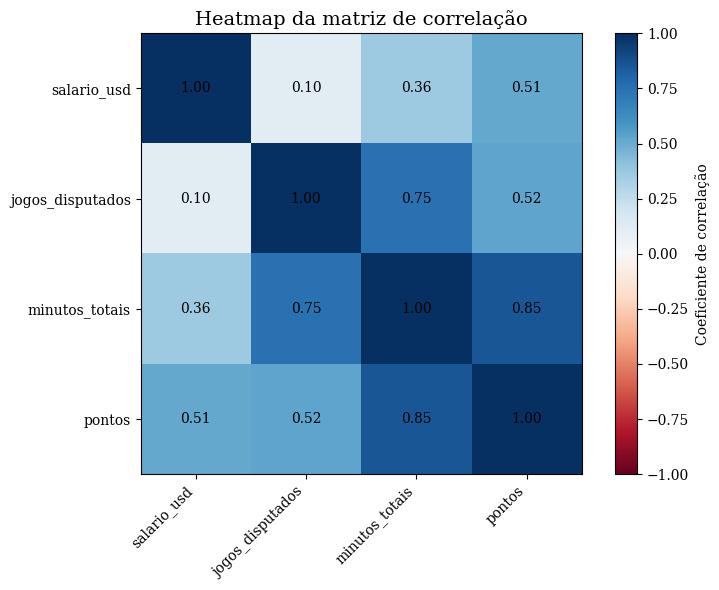

In [ ]:
# Heatmap da matriz de correlação
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(heat_correlação, cmap='RdBu', vmin=-1, vmax=1)
fig.colorbar(img, ax=ax, label='Coeficiente de correlação')
ax.set_xticks(range(len(heat_correlação.columns)))
ax.set_xticklabels(heat_correlação.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heat_correlação.index)))
ax.set_yticklabels(heat_correlação.index)

for i in range(len(heat_correlação.index)):
    for j in range(len(heat_correlação.columns)):
        ax.text(j, i, f'{heat_correlação.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Heatmap da matriz de correlação')
fig.tight_layout()
plt.show()

In [ ]:
# Filtrando jogadores em posições defensivas e posições ofensivas
posicao_ofensiva = ['PG', 'SG', 'G', 'SF']
posicao_defensiva = ['PF', 'C']

dfGS_ofensiva = dfGS_analise[dfGS_analise['sigla_posicao'].isin(posicao_ofensiva)].copy()
dfGS_defensiva = dfGS_analise[dfGS_analise['sigla_posicao'].isin(posicao_defensiva)].copy()

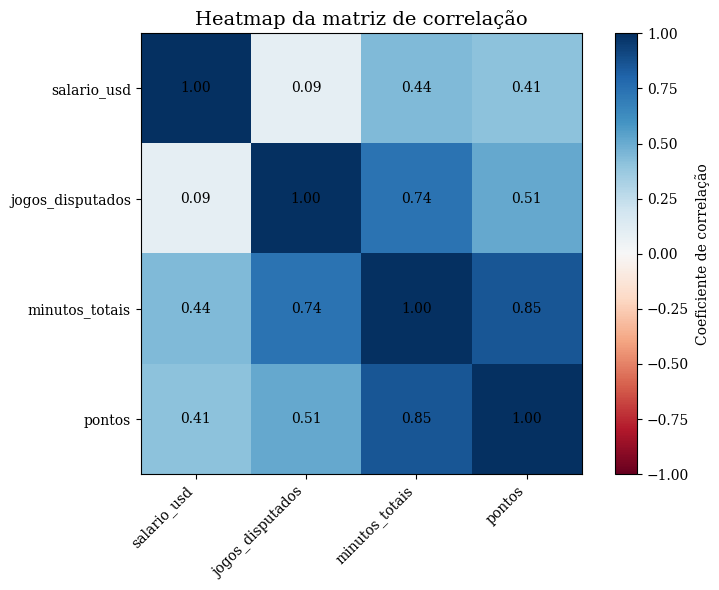

In [ ]:
# Avaliando só os jogadores em posições defensivas
vars_desempenho = ['salario_usd','jogos_disputados','minutos_totais','pontos']
heat_correlação = dfGS_defensiva[vars_desempenho].corr()
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(heat_correlação, cmap='RdBu', vmin=-1, vmax=1)
fig.colorbar(img, ax=ax, label='Coeficiente de correlação')
ax.set_xticks(range(len(heat_correlação.columns)))
ax.set_xticklabels(heat_correlação.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heat_correlação.index)))
ax.set_yticklabels(heat_correlação.index)

for i in range(len(heat_correlação.index)):
    for j in range(len(heat_correlação.columns)):
        ax.text(j, i, f'{heat_correlação.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Heatmap da matriz de correlação')
fig.tight_layout()
plt.show()

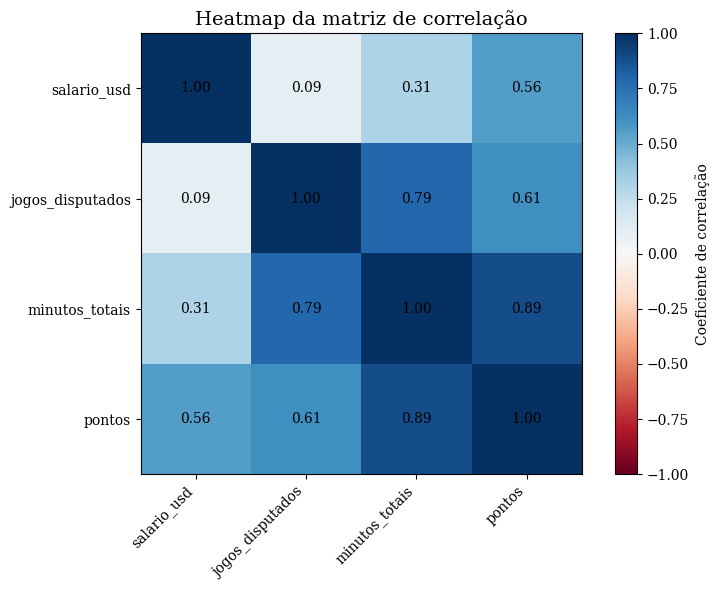

In [ ]:
# Avaliando só os jogadores em posições ofensivas
vars_desempenho = ['salario_usd','jogos_disputados','minutos_totais','pontos']
heat_correlação = dfGS_ofensiva[vars_desempenho].corr()
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(heat_correlação, cmap='RdBu', vmin=-1, vmax=1)
fig.colorbar(img, ax=ax, label='Coeficiente de correlação')
ax.set_xticks(range(len(heat_correlação.columns)))
ax.set_xticklabels(heat_correlação.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heat_correlação.index)))
ax.set_yticklabels(heat_correlação.index)

for i in range(len(heat_correlação.index)):
    for j in range(len(heat_correlação.columns)):
        ax.text(j, i, f'{heat_correlação.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Heatmap da matriz de correlação')
fig.tight_layout()
plt.show()

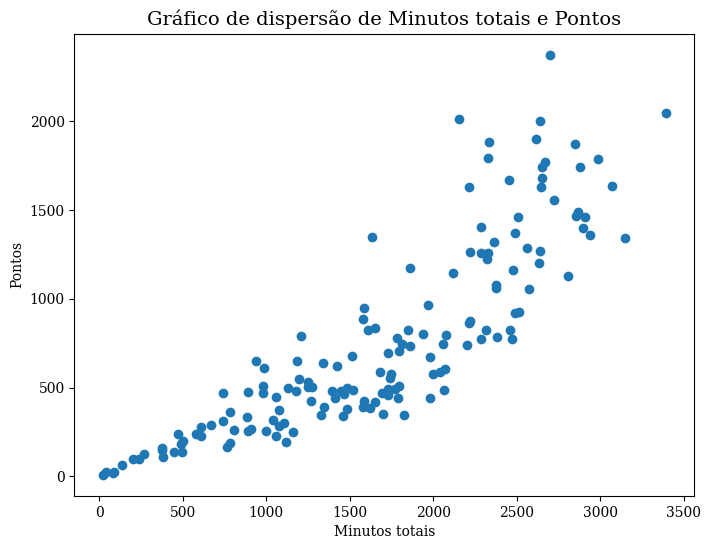

In [ ]:
# Gráfico de dispersão
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfGS_analise['minutos_totais'], dfGS_analise['pontos'])
ax.set_xlabel('Minutos totais')
ax.set_ylabel('Pontos')
ax.set_title('Gráfico de dispersão de Minutos totais e Pontos')
plt.show()

In [ ]:
# Covariância de Minutos totais e Pontos
covariancia = dfGS_analise['minutos_totais'].cov(dfGS_analise['pontos'])
print("Covariância de Minutos totais e Pontos:", covariancia)
if covariancia > 0:
    print("A relação entre Minutos totais e Pontos é positiva.")
elif covariancia < 0:
    print("A relação entre Minutos totais e Pontos é negativa.")

Covariância de Minutos totais e Pontos: 364042.04798761616
A relação entre Minutos totais e Pontos é positiva.


In [ ]:
# Correlação de Pearson de minutos totais e Pontos
correlacao = dfGS_analise['minutos_totais'].corr(dfGS_analise['pontos'])
print("Correlação de Pearson de Minutos totais e Pontos:", correlacao)

Correlação de Pearson de Minutos totais e Pontos: 0.8532823335520824


Muitos jogadores que fizeram uma alta quantidade de pontos, tiveram também tiveram um alto tempo de jogo, até mesmo jogadores de posições defensivas.

# Parte 2: Variável Aleatória Discreta

In [ ]:
# Métricas de desempenho a serem avaliadas
metricas_desempenho = [
    'jogos_disputados',
    'minutos_totais',
    'pontos'
]

# Calcular o primeiro quartil (Q1) para cada métrica
q1 = dfGS_analise[metricas_desempenho].quantile(0.25)

print("Limites do Primeiro Quartil (q1) para cada métrica:")
print(q1)

# Inicializar uma nova coluna para contar os indicadores de baixo desempenho
dfGS_analise['num_indicadores_baixo_desempenho'] = 0

# Contar os indicadores de baixo desempenho para cada jogador-temporada
for metric in metricas_desempenho:
    dfGS_analise['num_indicadores_baixo_desempenho'] += (
        dfGS_analise[metric] < q1[metric]
    ).astype(int)

display(dfGS_analise[['nome_jogador', 'temporada'] + metricas_desempenho + ['num_indicadores_baixo_desempenho']].head(10))

Limites do Primeiro Quartil (q1) para cada métrica:
jogos_disputados      53.0
minutos_totais      1074.0
pontos               365.0
Name: 0.25, dtype: float64


,nome_jogador,temporada,jogos_disputados,minutos_totais,pontos,num_indicadores_baixo_desempenho
217,Mookie Blaylock,2000,73.0,2459.0,822.0,0
1219,Vonteego Cummings,2000,75.0,1793.0,706.0,0
549,Erick Dampier,1999,50.0,1414.0,442.0,1
550,Erick Dampier,2001,43.0,1038.0,319.0,3
551,Erick Dampier,2002,73.0,1740.0,554.0,0
552,Erick Dampier,2003,82.0,1978.0,673.0,0
1363,Baron Davis,2005,46.0,1581.0,885.0,1
1364,Baron Davis,2006,54.0,1971.0,967.0,0
1365,Baron Davis,2007,63.0,2221.0,1264.0,0
735,Derek Fisher,2005,74.0,2222.0,877.0,0


In [ ]:
# Tabela com P(X = x) - Função de Massa de Probabilidade (FMP)
# Calcula a frequência de cada valor de X(indicadores de baixo desempenho) e divide pelo total de observações
px_values = dfGS_analise['num_indicadores_baixo_desempenho'].value_counts(normalize=True).sort_index()
px_df = px_values.reset_index()
px_df.columns = ['X', 'Probabilidade']

display(px_df)

,X,Probabilidade
0,0,0.640523
1,1,0.124183
2,2,0.091503
3,3,0.143791


In [ ]:
# Tabela com P(X <= x) - Função de Distribuição Acumulada (FDA)
Px_values = px_values.cumsum()
Px_df = Px_values.reset_index()
Px_df.columns = ['X', 'Probabilidade_Acumulada']
print("Função de Distribuição Acumulada (P(X<=x)):")

display(Px_df)

Função de Distribuição Acumulada (P(X<=x)):


,X,Probabilidade_Acumulada
0,0,0.640523
1,1,0.764706
2,2,0.856209
3,3,1.000000


In [ ]:
# Média da variável aleatória discreta X

media_x = dfGS_analise['num_indicadores_baixo_desempenho'].mean()

print("Média de X:", round(media_x, 2))

Média de X: 0.74


In [ ]:
# Desvio padrão da variável aleatória discreta X

desvio_padrao_x = dfGS_analise['num_indicadores_baixo_desempenho'].std()

print("Desvio padrão de X:", round(desvio_padrao_x, 2))

Desvio padrão de X: 1.12


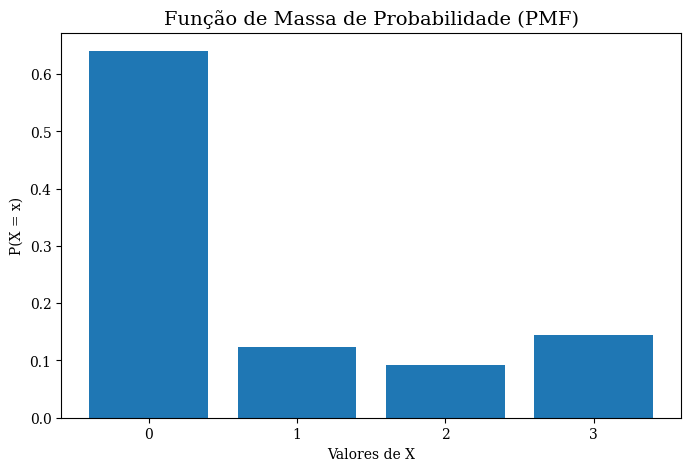

In [ ]:
# Gráfico da PMF

plt.figure(figsize=(8,5))

plt.bar(
    px_df['X'],
    px_df['Probabilidade']
)

plt.xlabel('Valores de X')
plt.ylabel('P(X = x)')
plt.title('Função de Massa de Probabilidade (PMF)')

plt.xticks([0,1,2,3])

plt.show()

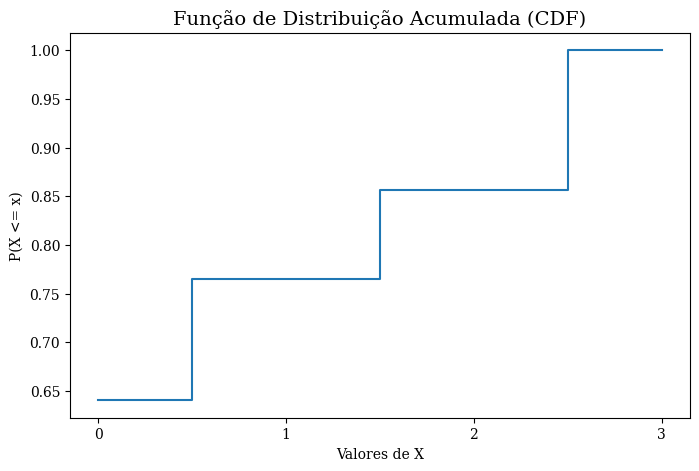

In [ ]:
# Gráfico da CDF

plt.figure(figsize=(8,5))

plt.step(
    Px_df['X'],
    Px_df['Probabilidade_Acumulada'],
    where='mid'
)

plt.xlabel('Valores de X')
plt.ylabel('P(X <= x)')
plt.title('Função de Distribuição Acumulada (CDF)')

plt.xticks([0,1,2,3])

plt.show()

A variável aleatória discreta X representa a quantidade de indicadores de baixo desempenho observados em cada caso jogador-temporada.

Valores próximos de 0 representam jogadores com maior participação e melhor desempenho relativo.

Valores próximos de 3 representam jogadores com baixo desempenho simultâneo em múltiplos critérios analisados.

# Parte 3: Associação Entre Eventos


In [ ]:
# Evento:
# B = baixo desempenho
# S = nao_permanencia

# Definição de baixo desempenho:
# X >= 2

dfGS_analise['baixo_desempenho'] = (
    dfGS_analise['num_indicadores_baixo_desempenho'] >= 2
)

dfGS_analise[[
    'nome_jogador',
    'temporada',
    'num_indicadores_baixo_desempenho',
    'baixo_desempenho'
]].head(10)

,nome_jogador,temporada,num_indicadores_baixo_desempenho,baixo_desempenho
217,Mookie Blaylock,2000,0,False
1219,Vonteego Cummings,2000,0,False
549,Erick Dampier,1999,1,False
550,Erick Dampier,2001,3,True
551,Erick Dampier,2002,0,False
552,Erick Dampier,2003,0,False
1363,Baron Davis,2005,1,False
1364,Baron Davis,2006,0,False
1365,Baron Davis,2007,0,False
735,Derek Fisher,2005,0,False


In [ ]:
# Probabilidade condicional P(S | B)

ps_b = (
    dfGS_analise[
        dfGS_analise['baixo_desempenho'] == True
    ]['nao_permanencia']
    .mean()
)

print("P(S | B):", round(ps_b, 4))

P(S | B): 0.0556


In [ ]:
# Probabilidade condicional P(S | não B)

ps_nao_b = (
    dfGS_analise[
        dfGS_analise['baixo_desempenho'] == False
    ]['nao_permanencia']
    .mean()
)

print("P(S | não B):", round(ps_nao_b, 4))

P(S | não B): 0.0855


In [ ]:
# Diferença entre as probabilidades

diferenca = ps_b - ps_nao_b

print(
    "Diferença entre P(S | B) e P(S | não B):",
    round(diferenca, 4)
)

Diferença entre P(S | B) e P(S | não B): -0.0299


Os resultados sugerem que casos classificados como baixo desempenho apresentaram maior frequência de não permanência observada no mesmo time na temporada seguinte.

Entretanto, a análise é observacional e não permite afirmar causalidade.

A não permanência pode ocorrer por fatores como trocas, aposentadoria, lesões, estratégia financeira ou decisões técnicas da franquia.

# CONCLUSÃO

A análise realizada com os dados do Golden State Warriors permitiu investigar associações observacionais entre desempenho, utilização em quadra, salário e não permanência observada no mesmo time na temporada seguinte.

A matriz de correlação indicou associação linear positiva entre minutos totais, pontos e jogos disputados, sugerindo que jogadores mais utilizados tendem a apresentar maior produção ofensiva.

A relação entre salário e desempenho também apresentou associação positiva, embora com intensidade moderada, indicando que jogadores mais produtivos tendem a receber salários maiores.

A variável aleatória discreta X permitiu representar quantitativamente o número de indicadores de baixo desempenho presentes em cada caso jogador-temporada.

Os resultados mostraram que a maior parte dos casos concentrou-se em valores baixos de X, enquanto poucos jogadores apresentaram simultaneamente múltiplos indicadores negativos de desempenho.

Ao comparar as probabilidades condicionais, observou-se que a não permanência observada foi mais frequente entre os casos classificados como baixo desempenho.

Isso sugere associação observacional entre desempenho reduzido e ausência do jogador no mesmo time na temporada seguinte.

Entretanto, a análise possui limitações importantes, já que fatores como lesões, trocas, aposentadoria e estratégias salariais não estão representados diretamente no dataset.

Portanto, os resultados não permitem concluir causalidade entre desempenho e saída de jogadores da equipe.